## IC Redshift


The grid scale is 
$$
L_\text{grid}=\frac{L_\text{box}}{N_\text{grid}}
$$
where
- $L_\text{box} =$ simulation box size 
- $N_\text{grid} =$ number of particles per dimension

The density fluction smoothed over scale $R$ is given by
$$
\delta_R(\vec{x})=\int \delta(\vec{y})W_R(\vec{y}-\vec{x})d^3y
$$

The mean RMS linear density fluctuation smoothed on the scale $R$, i.e. $\sigma(R,z)$ , is given by (Padmanabhan Eq-5.107)
$$
\sigma^2(R,z)=\left< \delta^2_R(\vec{x}) \right> = \int_0^\infty \frac{k^2 dk}{2\pi^2} P(k,z) \left|W_R(kR)\right|^2
$$
where
- $P(k,z)$ is the linear matter power spectrum
- $W_R(kR)$ is the smoothing window over scale $R$

We need to compute $\sigma_{L_\text{grid}}$ which is the means the RMS linear density fluctuation smoothed on the scale of one grid cell (or inter-particle spacing). This is given by
$$
\sigma^2(L_\text{grid},z)=\int_0^\infty \frac{k^2 dk}{2\pi^2} P(k,z) \left|W(kL_\text{grid})\right|^2
$$

Common choices for smoothing is a top-hat smoothing
$$
W_R(\vec{r})=\frac{1}{\left(\frac{4}{3}\pi R^3\right)}\Theta(R-r) \Longleftrightarrow W_R(k)=\frac{3(\sin kR-kR \cos kR)}{(kR)^3}
$$
Or with $kR=x$
$$
 W(x)=\frac{3(\sin x - x \cos x)}{x^3}
$$
and power spectrum is calculated using codes like CLASS or CAMB.

### Practical procedure
1. Generate P(k,z=0) using CLASS (or CAMB) - Done is another tutorial.
2. Compute $\sigma(L_\text{grid},0)$.
3. Scale to redshift $z$:
   $$\sigma(L_\text{grid},z)=D(z)\sigma(L_\text{grid},0)$$
   where $D(z)$ is the linear growth factor normalised to $D(0)=1$.
4. Choose $z_\text{init}$ such that 
   $$
   \sigma_{L_\text{grid}}(z_\text{init}) \lesssim \epsilon
   $$
   where
   - $\epsilon \sim 0.1-0.2$ for 2LPT IC.
   - $\epsilon \sim 0.05-0.1$ for Zeldovich (1LPT) IC.
   
   Note that the smallest scale (largest k-mode) enters non-linear evolution first.





### STEP - 1 : The Power Spectrum
Since we have already cached the power spectrum, we will read it from there.


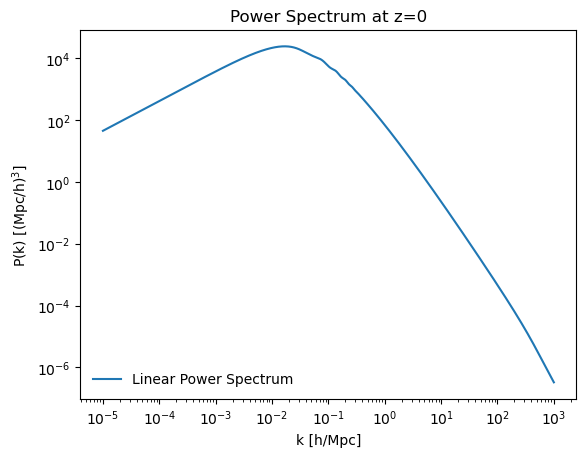

In [1]:
import numpy as np
import matplotlib.pyplot as plt

PK_PATH = "/home/ranit/gfs/cache/classy_pk_z0.txt"
k,pk_lin,_ = np.loadtxt(PK_PATH,unpack=True)   

plt.loglog(k, pk_lin, label='Linear Power Spectrum')
plt.xlabel('k [h/Mpc]')
plt.ylabel('P(k) [(Mpc/h)$^3$]')
plt.title(f'Power Spectrum at z=0')
plt.legend(frameon=False, loc='lower left')
plt.show()


## STEP - 2 : RMS linear density fluctuations at z=0

We need to integrate
$$
\sigma^2(L_\text{grid},z=0)=\int_0^\infty \frac{k^2 dk}{2\pi^2} P(k,z=0) \left|W(kL_\text{grid})\right|^2
$$
with top-hat filter
$$
W(x)=\frac{3(\sin x - x \cos x)}{x^3}
$$

In [2]:
def top_hat(x):
    return 3*(np.sin(x)-x*np.cos(x))/(x**3)


from scipy.interpolate import interp1d
def Pk_interpolated(kk):
    pk_interp = interp1d(k, pk_lin, kind='cubic', fill_value="extrapolate")
    return pk_interp(kk)

def integrand(k,R):
    x = k*R
    W = top_hat(x)
    Pkk = Pk_interpolated(k)
    I = (k**2) * (Pkk) * (W**2)
    I = I/(2*np.pi**2)
    return I

from scipy.integrate import quad
def sigma_R(R):
    result, error = quad(integrand, 1e-6, 1e4, args=(R,), limit=500)
    return np.sqrt(result)


L_BOX = 200  # Mpc/h
N_GRID = 64
L_GRID = L_BOX / N_GRID  # Mpc/h
print(f"L_GRID: {L_GRID:.2f} Mpc/h")

sigma_L_grid = sigma_R(L_GRID)
print(f"Sigma(L_GRID) at z=0: {sigma_L_grid:.4f}")

sigma_L_8MPpc = sigma_R(8)
print(f"Sigma(8 Mpc/h) at z=0: {sigma_L_8MPpc:.4f}")


L_GRID: 3.12 Mpc/h
Sigma(L_GRID) at z=0: 1.4651
Sigma(8 Mpc/h) at z=0: 0.8256


/tmp/ipykernel_1394/631353832.py:20: IntegrationWarning: The algorithm does not converge.  Roundoff error is detected
  in the extrapolation table.  It is assumed that the requested tolerance
  cannot be achieved, and that the returned result (if full_output = 1) is 
  the best which can be obtained.
  result, error = quad(integrand, 1e-6, 1e4, args=(R,), limit=500)


### STEP - 3 : Scale back to redshift z
We need to evaluate the growth function $D(z)$ normalised to $D(z=0)=1$. The expression is given by (Refere Dodelson - section 7.5 - Eq. 7.77)
$$
\begin{align*}
D(a)&=\frac{5\Omega_m}{2} \frac{H(a)}{H_0} \int_0^a \frac{da'}{(a'H(a')/H_0)^3}\\
    &=\frac{5\Omega_m H_0^2}{2} H(a) \int_0^a \frac{da'}{(a'H(a'))^3}
\end{align*}
$$

So first we have to get $H(a)$. Its given by
$$
H(a) = H_0\sqrt{\Omega_{m}a^{-3} + \Omega_{r}a^{-4} + \Omega_{\Lambda} + \Omega_{k}a^{-2}}
$$
In Flat-LCDM,
- $\Omega_k=0$
- $\Omega_r \sim 1e-5$ which can be ignored
- Then by definition $\Omega_\text{m}+\Omega_\Lambda=1 \implies \Omega_\Lambda = 1-\Omega_m$
We then have 
$$
H(a) = H_0\sqrt{\Omega_{m}a^{-3} + (1 - \Omega_{\Lambda})}
$$


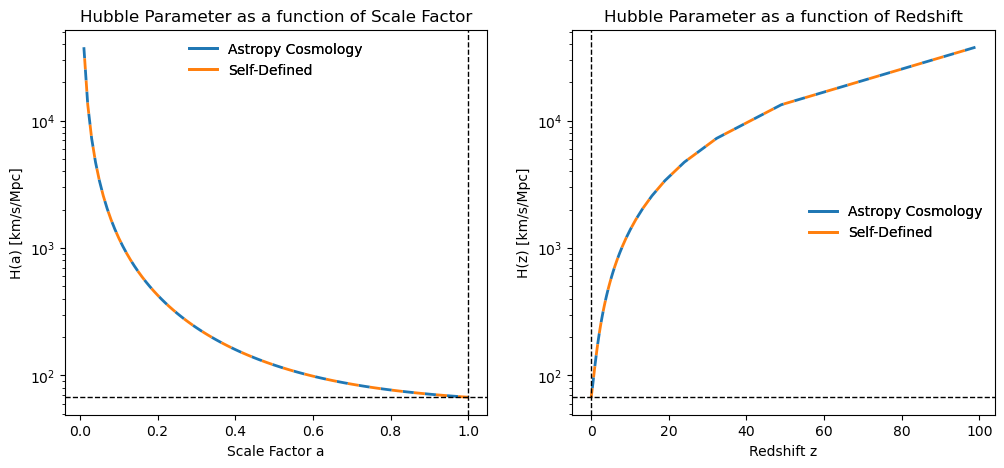

In [3]:
from astropy.cosmology import FlatLambdaCDM
cosmo = FlatLambdaCDM(H0=67.36, Om0=0.3153)
def H(a):
    return cosmo.H(1/a - 1).value  # Hubble parameter in km/s/Mpc

def H_self(a):  # for flat LambdaCDM
    H0 = 67.36
    Om0 = 0.3153
    return H0 * np.sqrt(Om0 * a**(-3) + (1 - Om0))  # H(a) in km/s/Mpc


a = np.linspace(0.01, 1, 100)
z= 1/a - 1
H_a = H(a)
H_a_self = H_self(a)


# Plotting H(a) and H(z)
fig,axs=plt.subplots(1,2, figsize=(12, 5))
axs[0].plot(a, H_a,lw=2,ls=(0,(4,4)),label='Astropy Cosmology',color='C0')
axs[0].plot(a, H_a_self, lw=2,ls=(4,(4,4)),label='Self-Defined',color='C1')
axs[0].set_xlabel('Scale Factor a')
axs[0].set_ylabel('H(a) [km/s/Mpc]')

axs[1].plot(z, H_a,lw=2,ls=(0,(4,4)),label='Astropy Cosmology',color='C0')
axs[1].plot(z, H_a_self, lw=2,ls=(4,(4,4)),label='Self-Defined',color='C1')
axs[1].set_xlabel('Redshift z')
axs[1].set_ylabel('H(z) [km/s/Mpc]')

axs[0].set_title('Hubble Parameter as a function of Scale Factor')
axs[1].set_title('Hubble Parameter as a function of Redshift')

for ax in axs:
    ax.set_yscale('log')
    ax.axhline(67.36,color='k', ls='--',lw=1)

axs[0].axvline(1, color='k', ls='--',lw=1)
axs[1].axvline(0, color='k', ls='--',lw=1)

from matplotlib.lines import Line2D
custom_lines = [Line2D([0], [0], color='C0', lw=2,label='Astropy Cosmology'),
                    Line2D([0], [0], color='C1', lw=2,label='Self-Defined')]

for ax in axs:
    leg = ax.legend(handles=custom_lines, frameon=False)
    ax.add_artist(leg)


plt.show()


Okay lets find out the growth function now. To remind, we are calculating
$$
D(a)=\frac{5\Omega_m H_0^2}{2} H(a) \int_0^a \frac{da'}{(a'H(a'))^3}
$$
with $D(z=0)=1$.

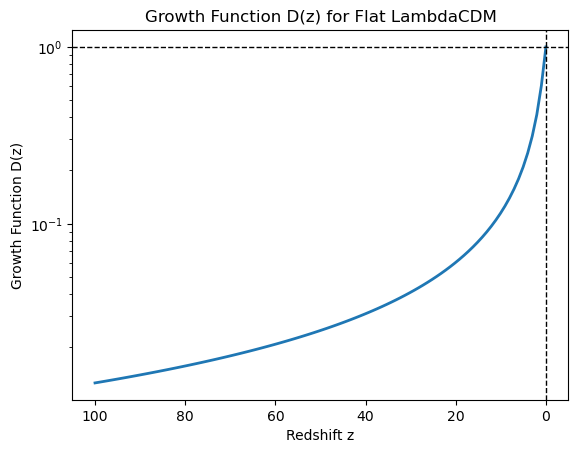

In [4]:
H0 = 67.36
Om0 = 0.3153

def H(a):  # for flat LambdaCDM
    return H0 * np.sqrt(Om0 * a**(-3) + (1 - Om0)) 

def integrand_D(ap):
    return 1/(ap*H(ap))**3

def D(a):
    integral, error = quad(integrand_D, 1e-6, a, limit=500)
    D_a = (5*Om0*H0**2/2) * H(a) * integral
    return D_a

def Dz(z):
    a = 1/(1+z)
    D0 = D(1)
    return D(a)


z = np.linspace(0, 100, 100)
D_z = np.array([Dz(zi) for zi in z])
D_0 = Dz(0)
D_z = D_z / D_0  # Normalize to D(0) = 1
plt.plot(z, D_z, lw=2)
plt.xlabel('Redshift z')
plt.ylabel('Growth Function D(z)')
plt.title('Growth Function D(z) for Flat LambdaCDM')
plt.axhline(1, color='k', ls='--', lw=1)
plt.axvline(0, color='k', ls='--', lw=1)
plt.yscale('log')
plt.gca().invert_xaxis()
plt.show()


### STEP 4 : Scale down RMS linear density fluction to redshift z
Remember the formula is
$$
\sigma(L_\text{grid},z)=D(z)\sigma(L_\text{grid},0)
$$

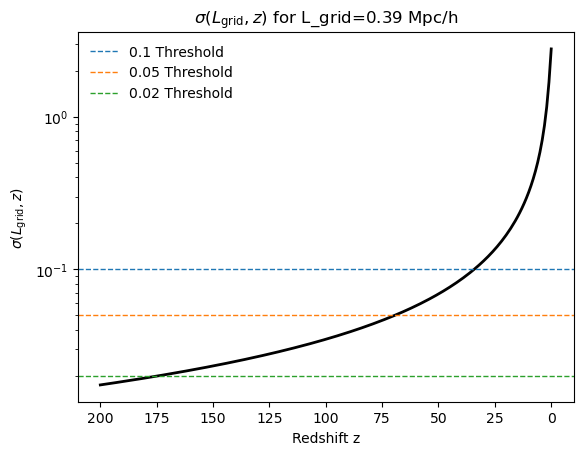

In [6]:
L_BOX = 50  # Mpc/h
N_GRID = 128
L_GRID = L_BOX / N_GRID  # Mpc/h

sigma_L_grid = sigma_R(L_GRID)
z = np.linspace(0, 200, 201)
Dz_z = np.array([Dz(zi) for zi in z])
sigma_L_grid_z = sigma_L_grid * Dz_z

# Plot
plt.plot(z, sigma_L_grid_z, lw=2,color='k')
plt.xlabel('Redshift z')
plt.ylabel(f'$\\sigma(L_{{\\text{{grid}}}},z)$')
plt.title(f'$\sigma(L_{{\\text{{grid}}}},z)$ for L_grid={L_GRID:.2f} Mpc/h')
plt.yscale('log')
plt.axhline(0.1, color='C0', lw=1,label='0.1 Threshold',ls='--')
plt.axhline(0.05, color='C1', lw=1,label='0.05 Threshold',ls='--')
plt.axhline(0.02, color='C2', lw=1,label='0.02 Threshold',ls='--')
plt.legend(frameon=False,loc='upper left')
plt.gca().invert_xaxis()
plt.show()